In [1]:
!pip install pyspark
!pip install pyarrow

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
basePath = '/content/drive/MyDrive/MOOCCubeX/Dataset/'
entitiesPath = basePath+'entities'
relationsPath = basePath+'relations'
!ls {basePath}
labelPath = '/content/drive/MyDrive/MOOCCubeX/Dataset/Data_cleaned/label_3_5(have_start_end_raw).csv'

course_filtered.csv	   entities
course_final_cleaned.csv   Label_3_and_5_classes.csv
course_limit_Nhom6.csv	   prerequisites
course_merged.csv	   relations
course_proportion.csv	   resource_exercise_course.parquet
Data_cleaned		   resource_video_course.parquet
data_for_Score_Struct.csv  user_course_use_labeling.parquet


In [4]:
import json
import gzip
import bz2
import orjson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def read_jsonl_in_batches(file_path, batch_size=10000, use_orjson=True):
    """
    Đọc file JSON Lines theo từng batch và yield DataFrame.

    Parameters
    ----------
    file_path : str
        Đường dẫn tới file JSONL (có thể nén .gz hoặc .bz2)
    batch_size : int
        Số dòng mỗi batch
    use_orjson : bool
        Sử dụng orjson để tăng tốc (nếu có cài đặt)

    Yields
    ------
    pd.DataFrame
        Batch dữ liệu dưới dạng DataFrame
    """

    # Chọn thư viện parse JSON
    json_loader = orjson.loads if use_orjson else json.loads

    # Chọn method mở file (hỗ trợ file nén)
    if file_path.endswith(".gz"):
        open_func = gzip.open
    elif file_path.endswith(".bz2"):
        open_func = bz2.open
    else:
        open_func = open

    total_lines = 0
    error_lines = 0
    batch = []

    try:
        with open_func(file_path, 'rt', encoding='utf-8') as file:
            for line_num, line in enumerate(file, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json_loader(line)
                    batch.append(obj)
                except Exception as e:
                    error_lines += 1
                    print(f"[Warning] Lỗi parse JSON tại dòng {line_num}: {e}")
                    continue

                if len(batch) >= batch_size:
                    yield pd.DataFrame(batch)
                    total_lines += len(batch)
                    batch = []

            # Batch cuối
            if batch:
                yield pd.DataFrame(batch)
                total_lines += len(batch)

    except FileNotFoundError:
        print(f"[Error] File không tồn tại: {file_path}")
    except Exception as e:
        print(f"[Error] Lỗi khi đọc file: {e}")

    print(f"[Done] Đọc xong {total_lines} dòng hợp lệ, {error_lines} dòng lỗi.")

Đọc dữ liệu file course.json và file user.json

In [5]:
user_df = pd.concat(read_jsonl_in_batches(entitiesPath+'/user.json', batch_size=10000), ignore_index=True)
print(user_df.shape)
# Số lượng null của mỗi cột
print(user_df.isnull().sum())

[Done] Đọc xong 3330294 dòng hợp lệ, 0 dòng lỗi.


/tmp/ipython-input-2196733094.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  user_df = pd.concat(read_jsonl_in_batches(entitiesPath+'/user.json', batch_size=10000), ignore_index=True)


(3330294, 7)
id                     0
name                  54
gender                54
school                54
year_of_birth    3281764
course_order           0
enroll_time            0
dtype: int64


In [6]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3330294 entries, 0 to 3330293
Data columns (total 7 columns):
 #   Column         Dtype  
---  ------         -----  
 0   id             object 
 1   name           object 
 2   gender         float64
 3   school         object 
 4   year_of_birth  float64
 5   course_order   object 
 6   enroll_time    object 
dtypes: float64(2), object(5)
memory usage: 177.9+ MB


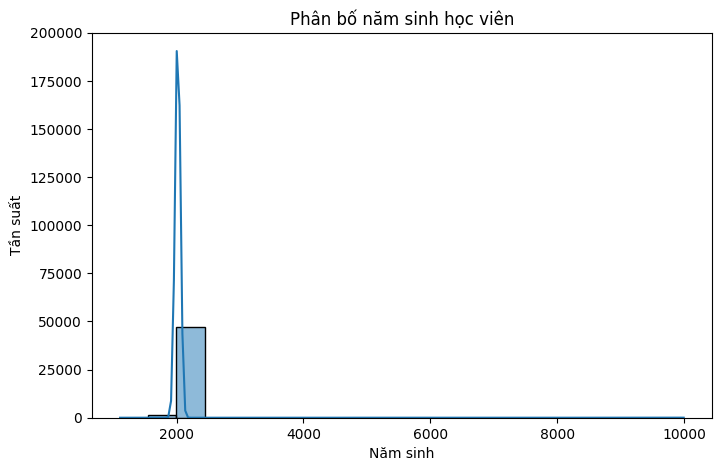

In [9]:
# Trực quan hóa năm sinh của học viên
plt.figure(figsize=(8, 5))
sns.histplot(user_df['year_of_birth'], bins=20, kde=True)
plt.xlabel('Năm sinh')
plt.ylabel('Tần suất')
plt.title('Phân bố năm sinh học viên')
plt.show()


In [12]:
user_df['year_of_birth'].describe()

,year_of_birth
count,48530.000000
mean,2039.016299
std,358.674303
min,1111.000000
25%,2020.000000
50%,2020.000000
75%,2020.000000
max,9989.000000


In [ ]:
# Doc du lieu file course_data.parquet
course_df = pd.read_parquet('/content/drive/MyDrive/MOOCCubeX/EDA2/entities/courses_data.parquet')
course_df

,course_id,name,field,about,video_counts,ex_counts,school_name,school_about,teacher_name,teacher_about
0,C_1017355,中医英语入门,[],中医药文化——中华文化的瑰宝和精髓，需要我们每一位国人传承和弘扬！如何开始用英语讲中医故事？...,19,19,广州中医药大学,广州中医药大学（Guangzhou University of Chinese Medici...,"[苏红, 刘帅帅, 张小虎, 何柳, 孟宪友]",[英语语言学硕士；现任广州中医药大学外国语学院院长；广州中医药大学中医翻译与国际传播研究中心...
1,C_1017419,智慧政府漫谈,[],本课程结合具体的交通拥堵、雾霾、看病难、食品安全等案例，漫谈智慧政府，让智慧政府变得不再抽象。,17,9,中南民族大学,中南民族大学（South-Central Minzu University），简称中南民大（...,"[胡新丽, 吴开松, 彭庆军, 方付建, 李世颉, 吴艳艳, 王文友, 王志华]","[管理学博士，副教授，行政管理系主任,学院外事秘书。2011年8月获国家留学基金委资助赴美国..."
2,C_1025064,思想政治教育学原理,[],亲爱的同学你好！你想知道思想政治教育是怎样产生和发展的吗？ 思想与行为是如何相互转化的？在思...,89,14,中南大学,中南大学（Central South University），位于湖南省长沙市，是中华人民共...,"[刘伟, 刘勇为, 林洁, 郭鹏飞, 贺才乐]",[刘伟，男，1968年出生于湖南省衡南县。1990年毕业于湘潭大学，获思想政治教育专业法学学...
3,C_1025076,轮滑高级教程,[],体验轮滑运动快乐真谛在于，对滑行速度提升的不断追求，对炫酷新颖的花样动作的不断尝试，以及交替...,43,4,东北大学,"东北大学（Northeastern University, NEU），坐落于辽宁省沈阳市，是...",[厉中山],[东北大学轮滑项目专任教师，体育教育训练学硕士，轮滑全国冠军，轮滑项目国家级运动健将，速度轮...
4,C_1025079,科学健身法-缠丝健身功,[],缠丝功是解决人类“进化病”的中国方案。面对肩颈僵硬，腰酸背疼，头昏脑涨，北京...,34,5,北京体育大学,北京体育大学（Beijing Sport University），简称北体大，由国家体育总局...,[武冬],[教授，教育学博士，博导，北京市教学名师，北京体育大学中国武术学院武术套路教研室副主任，国际...
...,...,...,...,...,...,...,...,...,...,...
3716,C_955163,学做小程序——实战篇：树洞小程序,[],本课程是由清华大学软件学院和乐享其约共同制作的微信小程序学习教程，由“乐享其约”资深项目经理...,101,7,清华大学,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,"[刘强, 施建锋, 伊甸, 小程序慕课讲师]",[刘强，清华大学软件学院副教授，研究生导师，担任教育部软件工程专业教学指导分委员会委员，国家...
3717,C_956128,肝硬化门脉高压热点问题解读,[],门脉高压热点问题解读,27,7,山东大学,山东大学（Shandong University），由中华人民共和国教育部直属，中央直管副部...,"[高艳景, 程宝泉, 周涛]",[高艳景，主任医师，教授。主持山东省自然科学基金、济南市科技发展计划（高校自主创新）、山东省...
3718,C_956129,游戏与电竞概论,[],游戏产业从设计开发、运营服务到电子竞技都已经成为当下热门的职业。本课深入探讨游戏电竞过去与未...,73,23,广州科技贸易职业学院,广州科技贸易职业学院，位于广东省广州市，是经广东省政府批准、国家教育部备案的广州市属公办全日...,"[邬厚民, 陈赞蔚, 梁斌, 朱恺文]",[邬厚民，副教授，广州科技贸易职业学院信息工程学院院长，广东省高校优秀青年教师，广东省“千百...
3719,C_956130,多媒体技术及应用,[],本课程主要学习多媒体技术的基本概念，学会使用多媒体硬件设备和多媒体软件环境，从应用的角度出发...,71,15,华南理工大学,华南理工大学（South China University of Technology），简...,"[郭芬, 林育蓓, 陆芳]",[郭芬，博士，华南理工大学软件学院高级实验师，主要研究领域为云计算应用技术及数据库技术。 从...


In [ ]:
# Explode cot course_order va enroll_time
user_df = user_df.explode(['course_order','enroll_time'])
user_df

,id,name,gender,school,year_of_birth,course_order,enroll_time
0,U_22,我,0.0,,2015.0,682129,2019-10-12 10:28:02
0,U_22,我,0.0,,2015.0,2294668,2020-11-21 14:03:28
1,U_24,王帅国,1.0,清华大学,6558.0,597214,2019-05-20 16:06:48
1,U_24,王帅国,1.0,清华大学,6558.0,605512,2019-05-24 19:34:43
1,U_24,王帅国,1.0,清华大学,6558.0,597211,2019-06-11 02:50:04
...,...,...,...,...,...,...,...
3330293,U_34712115,,1.0,,NaN,770738,2020-10-12 07:17:41
3330293,U_34712115,,1.0,,NaN,676937,2020-10-20 20:32:10
3330293,U_34712115,,1.0,,NaN,694136,2020-10-20 20:33:38
3330293,U_34712115,,1.0,,NaN,1738993,2020-10-20 20:35:18


In [ ]:
# Them ky tu C_ vao cot course_order
user_df['course_order'] = user_df['course_order'].apply(lambda x: 'C_' + str(x))
# Loai bo nhung dong du lieu co course_order khong nam trong course_id cua course_df
user_df = user_df[user_df['course_order'].isin(course_df['course_id'])]
user_df

,id,name,gender,school,year_of_birth,course_order,enroll_time
0,U_22,我,0.0,,2015.0,C_682129,2019-10-12 10:28:02
1,U_24,王帅国,1.0,清华大学,6558.0,C_597314,2019-06-12 17:22:07
1,U_24,王帅国,1.0,清华大学,6558.0,C_597208,2019-06-17 15:22:41
1,U_24,王帅国,1.0,清华大学,6558.0,C_682129,2019-10-06 16:23:51
1,U_24,王帅国,1.0,清华大学,6558.0,C_674910,2019-10-08 17:51:04
...,...,...,...,...,...,...,...
3330292,U_34712114,,1.0,,NaN,C_735405,2020-10-12 03:57:05
3330293,U_34712115,,1.0,,NaN,C_676937,2020-10-20 20:32:10
3330293,U_34712115,,1.0,,NaN,C_694136,2020-10-20 20:33:38
3330293,U_34712115,,1.0,,NaN,C_1738993,2020-10-20 20:35:18


In [ ]:
user_id_label = pd.read_csv(labelPath)
user_id_label = user_id_label['user_id'].drop_duplicates()
user_df = user_df[user_df['id'].isin(user_id_label)]
user_df

,id,name,gender,school,year_of_birth,course_order,enroll_time
1,U_24,王帅国,1.0,清华大学,6558.0,C_597314,2019-06-12 17:22:07
1,U_24,王帅国,1.0,清华大学,6558.0,C_597208,2019-06-17 15:22:41
1,U_24,王帅国,1.0,清华大学,6558.0,C_682129,2019-10-06 16:23:51
1,U_24,王帅国,1.0,清华大学,6558.0,C_674910,2019-10-08 17:51:04
1,U_24,王帅国,1.0,清华大学,6558.0,C_707038,2019-10-13 13:06:25
...,...,...,...,...,...,...,...
3330290,U_34712111,,2.0,,NaN,C_2199449,2020-10-12 03:46:08
3330293,U_34712115,,1.0,,NaN,C_676937,2020-10-20 20:32:10
3330293,U_34712115,,1.0,,NaN,C_694136,2020-10-20 20:33:38
3330293,U_34712115,,1.0,,NaN,C_1738993,2020-10-20 20:35:18


In [ ]:
# Gom nhom theo user_id giu nguyen cac cot khac va tao list course_order va enroll_time
# Rename cot id
user_df = user_df.rename(columns={'id': 'user_id'})
user_df = user_df.groupby('user_id').agg({
    'name': 'first',
    'gender': 'first',
    'school': 'first',
    'course_order': list,
    'enroll_time': list}).reset_index()
user_df

,user_id,name,gender,school,course_order,enroll_time
0,U_10000,PYQ,0.0,,"[C_680963, C_2033958]","[2020-06-07 16:51:56, 2020-10-27 09:07:30]"
1,U_1000129,李明东,0.0,云南民族大学,"[C_735210, C_1925903, C_1992970, C_680884, C_1...","[2020-09-05 17:55:11, 2020-09-06 14:37:17, 202..."
2,U_1000342,王怀权,0.0,云南民族大学,"[C_696968, C_696994, C_697791, C_948409, C_696...","[2020-02-04 12:22:04, 2020-02-04 12:28:15, 202..."
3,U_1000454,李燕,2.0,楚雄师范学院,"[C_2199449, C_629559, C_697032]","[2020-10-12 13:24:59, 2020-10-14 17:54:24, 202..."
4,U_1000663,先腾桂,1.0,少岷职业技术学校,[C_2328510],[2020-11-27 22:41:36]
...,...,...,...,...,...,...
1201557,U_999500,哎呦呦呦,2.0,大连外国语大学,"[C_694136, C_696954, C_735241, C_676917, C_696...","[2020-04-11 02:11:15, 2020-04-11 02:15:35, 202..."
1201558,U_999768,文思维,1.0,湖南大学,[C_943223],[2020-02-19 15:03:00]
1201559,U_999821,石展铭,0.0,北京科技大学,"[C_682702, C_696724, C_735395, C_677004, C_682...","[2019-12-29 19:35:58, 2019-12-30 06:22:37, 202..."
1201560,U_999856,李昊东41503244,0.0,北京科技大学,"[C_696724, C_696827, C_696994, C_947252, C_697...","[2020-02-23 20:24:59, 2020-02-25 16:13:15, 202..."


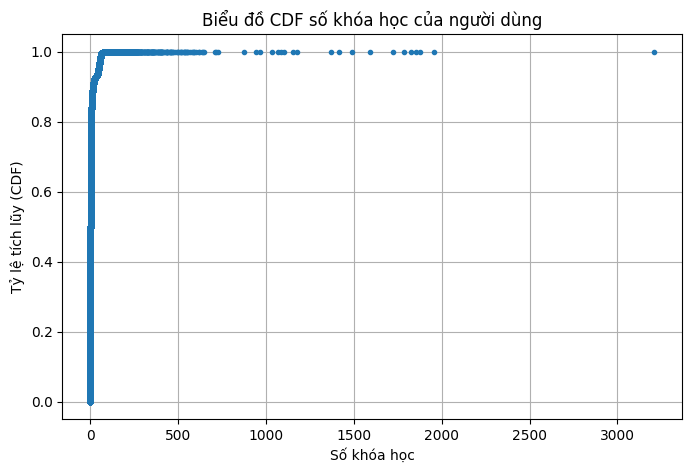

In [ ]:
import numpy as np
# Xử lý trường dữ liệu course_order của dataframe user_df
# Tạo cột dữ liệu num_course_order
user_df['num_course_order'] = user_df['course_order'].apply(lambda x: len(x))
# Tạo biểu đồ Cumulative Distribution Function (CDF) cho cột dữ liệu num_course_order
CDF_num_courses = user_df['num_course_order'].to_numpy()
Sorted_num_courses = np.sort(CDF_num_courses)
CDF  = np.arange(1, len(Sorted_num_courses) + 1) / len(Sorted_num_courses)
plt.figure(figsize=(8, 5))
plt.plot(Sorted_num_courses, CDF, marker='.', linestyle='none')
plt.xlabel("Số khóa học")
plt.ylabel("Tỷ lệ tích lũy (CDF)")
plt.title("Biểu đồ CDF số khóa học của người dùng")
plt.grid(True)
plt.show()

In [ ]:
# # Đặt threshold cho dữ liệu user_df với điều kiệu số khóa học đã học >=5 và <=50 thì giữ lại
# user_df = user_df[(user_df['num_course_order'] >= 5) & (user_df['num_course_order'] <= 50)]
# # Kiểm tra số lượng null của mỗi cột dữ liệu trong user_df
# print(user_df.isnull().sum())

In [ ]:
user_df.shape

(1201562, 7)

In [ ]:
# Loại bỏ các dòng dữ liệu null của 3 trường name gender school
user_df = user_df.dropna(subset=['name', 'gender', 'school'])
# # Kiểm tra miền dữ liệu của trường year_of_birth
# print(user_df['year_of_birth'].describe())
# Loại bỏ cột dữ liệu year_of_birth
# Kiểm tra ngoại lệ cột dữ liệu gender
print(user_df['gender'].value_counts())

gender
0.0    417867
1.0    392166
2.0    391510
Name: count, dtype: int64


Dựa trên phân tích cột dữ liệu gender không có giá trị ngoại lệ. Đối với cột dữ liệu year_of_birth giá trị mean và std lỗi rất nghiêm trọng do vậy sẽ loại bỏ cột dữ liệu này.

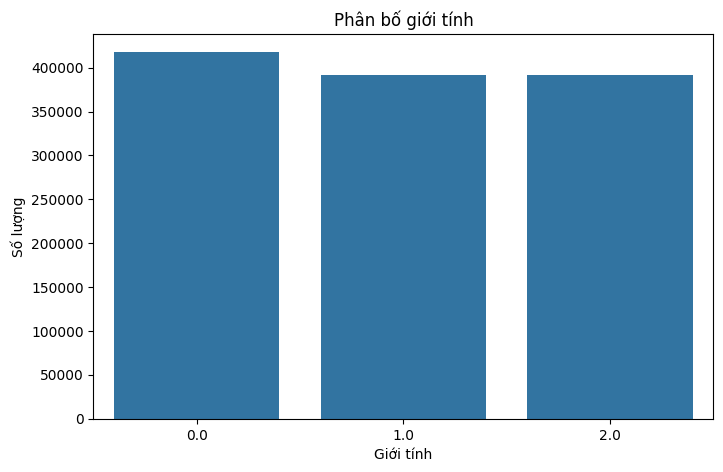

In [ ]:
# user_df = user_df.drop(columns=['year_of_birth'])
# Vẽ biểu đồ phân bố giới tính
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', data=user_df)
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.title('Phân bố giới tính')
plt.show()

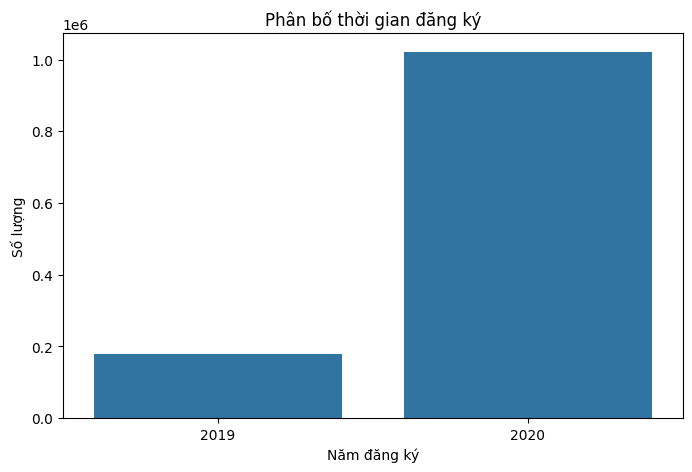

In [ ]:
import seaborn as sns

# Tạo Series chứa năm đăng ký (không thay đổi user_df)
enroll_year = pd.to_datetime(user_df['enroll_time'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x
), errors='coerce').dt.year

# Đếm số lượng theo năm
year_counts = enroll_year.value_counts().sort_index()

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.xlabel('Năm đăng ký')
plt.ylabel('Số lượng')
plt.title('Phân bố thời gian đăng ký')
plt.show()

In [ ]:
# Thêm cột iterval_enroll_time là mảng các khoảng thời gian đăng ký giữa 2 khóa học được làm tròn lên đơn vị ngày
import numpy as np
def calculate_interval_time(enroll_times):
    if not isinstance(enroll_times, list) or len(enroll_times) < 2:
        return None
    # Convert timestamps to datetime objects
    datetime_times = pd.to_datetime(enroll_times, errors='coerce', format='%Y-%m-%d %H:%M:%S')
    # Calculate the differences between consecutive timestamps
    time_diffs = datetime_times.diff().dropna()
    if time_diffs.empty:
        return None
    # Calculate the differences in days and round to 2 decimal places
    interval_days = (time_diffs.total_seconds() / (24 * 3600)).round(2)
    # Return the list of interval days
    return interval_days.tolist()

user_df['interval_enroll_time'] = user_df['enroll_time'].apply(calculate_interval_time)

/tmp/ipython-input-3815938915.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['interval_enroll_time'] = user_df['enroll_time'].apply(calculate_interval_time)


In [ ]:
user_df

,user_id,name,gender,school,course_order,enroll_time,num_course_order,interval_enroll_time
0,U_10000,PYQ,0.0,,"[C_680963, C_2033958]","[2020-06-07 16:51:56, 2020-10-27 09:07:30]",2,[141.68]
1,U_1000129,李明东,0.0,云南民族大学,"[C_735210, C_1925903, C_1992970, C_680884, C_1...","[2020-09-05 17:55:11, 2020-09-06 14:37:17, 202...",5,"[0.86, 0.01, 39.83, 45.4]"
2,U_1000342,王怀权,0.0,云南民族大学,"[C_696968, C_696994, C_697791, C_948409, C_696...","[2020-02-04 12:22:04, 2020-02-04 12:28:15, 202...",5,"[0.0, 23.92, 1.23, 5.3]"
3,U_1000454,李燕,2.0,楚雄师范学院,"[C_2199449, C_629559, C_697032]","[2020-10-12 13:24:59, 2020-10-14 17:54:24, 202...",3,"[2.19, 0.01]"
4,U_1000663,先腾桂,1.0,少岷职业技术学校,[C_2328510],[2020-11-27 22:41:36],1,None
...,...,...,...,...,...,...,...,...
1201557,U_999500,哎呦呦呦,2.0,大连外国语大学,"[C_694136, C_696954, C_735241, C_676917, C_696...","[2020-04-11 02:11:15, 2020-04-11 02:15:35, 202...",8,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.01]"
1201558,U_999768,文思维,1.0,湖南大学,[C_943223],[2020-02-19 15:03:00],1,None
1201559,U_999821,石展铭,0.0,北京科技大学,"[C_682702, C_696724, C_735395, C_677004, C_682...","[2019-12-29 19:35:58, 2019-12-30 06:22:37, 202...",12,"[0.45, 33.67, 1.51, 2.23, 4.78, 0.01, 0.0, 0.0..."
1201560,U_999856,李昊东41503244,0.0,北京科技大学,"[C_696724, C_696827, C_696994, C_947252, C_697...","[2020-02-23 20:24:59, 2020-02-25 16:13:15, 202...",7,"[1.83, 4.99, 0.01, 0.05, 0.0, 0.0]"


In [ ]:
# Tạo cột trung binh khoảng cách giữa các lần đăng ký
user_df['avg_interval_enroll_time'] = user_df['interval_enroll_time'].apply(lambda x: np.mean(x) if x is not None else None)
# Tạo cột khoảng thời gian lớn nhất và nhỏ nhất giữa các lần đăng ký
user_df['max_interval_enroll_time'] = user_df['interval_enroll_time'].apply(lambda x: np.max(x) if x is not None else None)
user_df['min_interval_enroll_time'] = user_df['interval_enroll_time'].apply(lambda x: np.min(x) if x is not None else None)
user_df

/tmp/ipython-input-536249664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['avg_interval_enroll_time'] = user_df['interval_enroll_time'].apply(lambda x: np.mean(x) if x is not None else None)
/tmp/ipython-input-536249664.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['max_interval_enroll_time'] = user_df['interval_enroll_time'].apply(lambda x: np.max(x) if x is not None else None)
/tmp/ipython-input-536249664.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

,user_id,name,gender,school,course_order,enroll_time,num_course_order,interval_enroll_time,avg_interval_enroll_time,max_interval_enroll_time,min_interval_enroll_time
0,U_10000,PYQ,0.0,,"[C_680963, C_2033958]","[2020-06-07 16:51:56, 2020-10-27 09:07:30]",2,[141.68],141.680000,141.68,141.68
1,U_1000129,李明东,0.0,云南民族大学,"[C_735210, C_1925903, C_1992970, C_680884, C_1...","[2020-09-05 17:55:11, 2020-09-06 14:37:17, 202...",5,"[0.86, 0.01, 39.83, 45.4]",21.525000,45.40,0.01
2,U_1000342,王怀权,0.0,云南民族大学,"[C_696968, C_696994, C_697791, C_948409, C_696...","[2020-02-04 12:22:04, 2020-02-04 12:28:15, 202...",5,"[0.0, 23.92, 1.23, 5.3]",7.612500,23.92,0.00
3,U_1000454,李燕,2.0,楚雄师范学院,"[C_2199449, C_629559, C_697032]","[2020-10-12 13:24:59, 2020-10-14 17:54:24, 202...",3,"[2.19, 0.01]",1.100000,2.19,0.01
4,U_1000663,先腾桂,1.0,少岷职业技术学校,[C_2328510],[2020-11-27 22:41:36],1,None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1201557,U_999500,哎呦呦呦,2.0,大连外国语大学,"[C_694136, C_696954, C_735241, C_676917, C_696...","[2020-04-11 02:11:15, 2020-04-11 02:15:35, 202...",8,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.01]",0.001429,0.01,0.00
1201558,U_999768,文思维,1.0,湖南大学,[C_943223],[2020-02-19 15:03:00],1,None,NaN,NaN,NaN
1201559,U_999821,石展铭,0.0,北京科技大学,"[C_682702, C_696724, C_735395, C_677004, C_682...","[2019-12-29 19:35:58, 2019-12-30 06:22:37, 202...",12,"[0.45, 33.67, 1.51, 2.23, 4.78, 0.01, 0.0, 0.0...",11.357273,79.88,0.00
1201560,U_999856,李昊东41503244,0.0,北京科技大学,"[C_696724, C_696827, C_696994, C_947252, C_697...","[2020-02-23 20:24:59, 2020-02-25 16:13:15, 202...",7,"[1.83, 4.99, 0.01, 0.05, 0.0, 0.0]",1.146667,4.99,0.00


In [ ]:
# Tach cot enroll_time thanh list year va month
user_df['enroll_time_datetime'] = user_df['enroll_time'].apply(lambda x: pd.to_datetime(x, errors='coerce',format='%Y-%m-%d %H:%M:%S'))
user_df['enroll_year_list'] = user_df['enroll_time_datetime'].apply(lambda x: [time.year for time in x])
user_df['enroll_month_list'] = user_df['enroll_time_datetime'].apply(lambda x: [time.month for time in x])
# Optionally, you can drop the intermediate 'enroll_time_datetime' column if you don't need it
user_df = user_df.drop(columns=['enroll_time_datetime'])

/tmp/ipython-input-1020356531.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['enroll_time_datetime'] = user_df['enroll_time'].apply(lambda x: pd.to_datetime(x, errors='coerce',format='%Y-%m-%d %H:%M:%S'))
/tmp/ipython-input-1020356531.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['enroll_year_list'] = user_df['enroll_time_datetime'].apply(lambda x: [time.year for time in x])
/tmp/ipython-input-1020356531.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [ ]:
# Tính trung bình số lượng khóa học mỗi tháng mà user đăng ký bằng cách đếm số lượng month list và chia theo 12
user_df['avg_courses_per_month'] = user_df['enroll_month_list'].apply(lambda x: np.mean(x) if x is not None else None)

In [ ]:
user_df.describe()

,gender,num_course_order,avg_interval_enroll_time,max_interval_enroll_time,min_interval_enroll_time,avg_courses_per_month
count,51419.000000,51419.000000,24728.000000,24728.000000,24728.000000,51419.000000
mean,1.056497,4.970108,41.482329,77.368453,26.878644,5.879602
std,0.811913,19.060168,55.660422,71.108283,56.280282,2.703633
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,1.000000,5.110000,15.010000,0.000000,3.500000
50%,1.000000,1.000000,18.652071,60.370000,0.030000,5.750000
75%,2.000000,3.000000,54.917000,123.812500,20.412500,8.181818
max,2.000000,1369.000000,400.760000,400.760000,400.760000,12.000000


In [ ]:


# First and last enrollment year/month
user_df['first_enroll_year'] = user_df['enroll_year_list'].apply(lambda x: x[0] if x else None)
user_df['last_enroll_year'] = user_df['enroll_year_list'].apply(lambda x: x[-1] if x else None)
# Most month enroll
user_df['most_enroll_month'] = user_df['enroll_month_list'].apply(lambda x: max(set(x), key=x.count) if x else None)

display(user_df.head())

,user_id,name,gender,school,course_order,enroll_time,num_course_order,interval_enroll_time,avg_interval_enroll_time,max_interval_enroll_time,min_interval_enroll_time,enroll_year_list,enroll_month_list,avg_courses_per_month,first_enroll_year,last_enroll_year,most_enroll_month
0,U_10000,PYQ,0.0,,"[C_680963, C_2033958]","[2020-06-07 16:51:56, 2020-10-27 09:07:30]",2,[141.68],141.6800,141.68,141.68,"[2020, 2020]","[6, 10]",8.0,2020,2020,10
1,U_1000129,李明东,0.0,云南民族大学,"[C_735210, C_1925903, C_1992970, C_680884, C_1...","[2020-09-05 17:55:11, 2020-09-06 14:37:17, 202...",5,"[0.86, 0.01, 39.83, 45.4]",21.5250,45.40,0.01,"[2020, 2020, 2020, 2020, 2020]","[9, 9, 9, 10, 11]",9.6,2020,2020,9
2,U_1000342,王怀权,0.0,云南民族大学,"[C_696968, C_696994, C_697791, C_948409, C_696...","[2020-02-04 12:22:04, 2020-02-04 12:28:15, 202...",5,"[0.0, 23.92, 1.23, 5.3]",7.6125,23.92,0.00,"[2020, 2020, 2020, 2020, 2020]","[2, 2, 2, 2, 3]",2.2,2020,2020,2
3,U_1000454,李燕,2.0,楚雄师范学院,"[C_2199449, C_629559, C_697032]","[2020-10-12 13:24:59, 2020-10-14 17:54:24, 202...",3,"[2.19, 0.01]",1.1000,2.19,0.01,"[2020, 2020, 2020]","[10, 10, 10]",10.0,2020,2020,10
4,U_1000663,先腾桂,1.0,少岷职业技术学校,[C_2328510],[2020-11-27 22:41:36],1,None,NaN,NaN,NaN,[2020],[11],11.0,2020,2020,11


In [ ]:
# Kiem tra so luong null moi cot
user_df.isnull().sum()

,0
user_id,0
name,0
gender,0
school,0
course_order,0
enroll_time,0
num_course_order,0
interval_enroll_time,599738
avg_interval_enroll_time,599738
max_interval_enroll_time,599738


In [ ]:
# Điền mảng rỗng vào interval_enroll_time, và giá trị 0 cho avg_interval_enroll_time, max_interval_enroll_time, min_interval_enroll_time
user_df['interval_enroll_time'] = user_df['interval_enroll_time'].apply(lambda x: x if x is not None else [])
user_df['avg_interval_enroll_time'] = user_df['avg_interval_enroll_time'].fillna(0)
user_df['max_interval_enroll_time'] = user_df['max_interval_enroll_time'].fillna(0)
user_df['min_interval_enroll_time'] = user_df['min_interval_enroll_time'].fillna(0)

# Kiểm tra lại số lượng null mỗi cột
print(user_df.isnull().sum())

user_id                     0
name                        0
gender                      0
school                      0
course_order                0
enroll_time                 0
num_course_order            0
interval_enroll_time        0
avg_interval_enroll_time    0
max_interval_enroll_time    0
min_interval_enroll_time    0
enroll_year_list            0
enroll_month_list           0
avg_courses_per_month       0
first_enroll_year           0
last_enroll_year            0
most_enroll_month           0
dtype: int64


In [ ]:
# Lưu trữ dataframe user_df trở lại drive
user_df.to_parquet('/content/drive/MyDrive/MOOCCubeX/EDA2/entities/user_data.parquet', index=False)

In [ ]:
# # Doc du lieu file user_data.parquet
# import pandas as pd
# user_df = pd.read_parquet(basePath+'EDA2/entities/courses_data.parquet')
# user_df.info()